In [65]:
import numpy as np 
import random
import matplotlib.pyplot as plt # Graphical library
#from sklearn.metrics import mean_squared_error # Mean-squared error function

# Coursework 1 :
See pdf for instructions. 

In [66]:
# WARNING: fill in these two functions that will be used by the auto-marking script
# [Action required]

def get_CID():
  return "01865438" # Return your CID (add 0 at the beginning to ensure it is 8 digits long)

def get_login():
  return "yh3620" # Return your short imperial login

## Helper class

In [67]:
# This class is used ONLY for graphics
# YOU DO NOT NEED to understand it to work on this coursework

class GraphicsMaze(object):

  def __init__(self, shape, locations, default_reward, obstacle_locs, absorbing_locs, absorbing_rewards, absorbing):

    self.shape = shape
    self.locations = locations
    self.absorbing = absorbing

    # Walls
    self.walls = np.zeros(self.shape)
    for ob in obstacle_locs:
      self.walls[ob] = 20

    # Rewards
    self.rewarders = np.ones(self.shape) * default_reward
    for i, rew in enumerate(absorbing_locs):
      self.rewarders[rew] = 10 if absorbing_rewards[i] > 0 else -10

    # Print the map to show it
    self.paint_maps()

  def paint_maps(self):
    """
    Print the Maze topology (obstacles, absorbing states and rewards)
    input: /
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders)
    plt.show()

  def paint_state(self, state):
    """
    Print one state on the Maze topology (obstacles, absorbing states and rewards)
    input: /
    output: /
    """
    states = np.zeros(self.shape)
    states[state] = 30
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders + states)
    plt.show()

  def draw_deterministic_policy(self, Policy):
    """
    Draw a deterministic policy
    input: Policy {np.array} -- policy to draw (should be an array of values between 0 and 3 (actions))
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders) # Create the graph of the Maze
    for state, action in enumerate(Policy):
      if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any action
        continue
      arrows = [r"$\uparrow$",r"$\rightarrow$", r"$\downarrow$", r"$\leftarrow$"] # List of arrows corresponding to each possible action
      action_arrow = arrows[action] # Take the corresponding action
      location = self.locations[state] # Compute its location on graph
      plt.text(location[1], location[0], action_arrow, ha='center', va='center') # Place it on graph
    plt.show()

  def draw_policy(self, Policy):
    """
    Draw a policy (draw an arrow in the most probable direction)
    input: Policy {np.array} -- policy to draw as probability
    output: /
    """
    deterministic_policy = np.array([np.argmax(Policy[row,:]) for row in range(Policy.shape[0])])
    self.draw_deterministic_policy(deterministic_policy)

  def draw_value(self, Value):
    """
    Draw a policy value
    input: Value {np.array} -- policy values to draw
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders) # Create the graph of the Maze
    for state, value in enumerate(Value):
      if(self.absorbing[0, state]): # If it is an absorbing state, don't plot any value
        continue
      location = self.locations[state] # Compute the value location on graph
      plt.text(location[1], location[0], round(value,2), ha='center', va='center') # Place it on graph
    plt.show()

  def draw_deterministic_policy_grid(self, Policies, title, n_columns, n_lines):
    """
    Draw a grid representing multiple deterministic policies
    input: Policies {np.array of np.array} -- array of policies to draw (each should be an array of values between 0 and 3 (actions))
    output: /
    """
    plt.figure(figsize=(20,8))
    for subplot in range (len(Policies)): # Go through all policies
      ax = plt.subplot(n_columns, n_lines, subplot+1) # Create a subplot for each policy
      ax.imshow(self.walls+self.rewarders) # Create the graph of the Maze
      for state, action in enumerate(Policies[subplot]):
        if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any action
          continue
        arrows = [r"$\uparrow$",r"$\rightarrow$", r"$\downarrow$", r"$\leftarrow$"] # List of arrows corresponding to each possible action
        action_arrow = arrows[action] # Take the corresponding action
        location = self.locations[state] # Compute its location on graph
        plt.text(location[1], location[0], action_arrow, ha='center', va='center') # Place it on graph
      ax.title.set_text(title[subplot]) # Set the title for the graph given as argument
    plt.show()

  def draw_policy_grid(self, Policies, title, n_columns, n_lines):
    """
    Draw a grid representing multiple policies (draw an arrow in the most probable direction)
    input: Policy {np.array} -- array of policies to draw as probability
    output: /
    """
    deterministic_policies = np.array([[np.argmax(Policy[row,:]) for row in range(Policy.shape[0])] for Policy in Policies])
    self.draw_deterministic_policy_grid(deterministic_policies, title, n_columns, n_lines)

  def draw_value_grid(self, Values, title, n_columns, n_lines):
    """
    Draw a grid representing multiple policy values
    input: Values {np.array of np.array} -- array of policy values to draw
    output: /
    """
    plt.figure(figsize=(20,8))
    for subplot in range (len(Values)): # Go through all values
      ax = plt.subplot(n_columns, n_lines, subplot+1) # Create a subplot for each value
      ax.imshow(self.walls+self.rewarders) # Create the graph of the Maze
      for state, value in enumerate(Values[subplot]):
        if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any value
          continue
        location = self.locations[state] # Compute the value location on graph
        plt.text(location[1], location[0], round(value,1), ha='center', va='center') # Place it on graph
      ax.title.set_text(title[subplot]) # Set the title for the graoh given as argument
    plt.show()


## Maze class

In [68]:
# This class define the Maze environment

class Maze(object):

  # [Action required]
  def __init__(self):
    """
    Maze initialisation.
    input: /
    output: /
    """
    
    # [Action required]
    # Properties set from the CID
    y = 3
    z = 8
    self._prob_success = 0.8+0.02*(9-y) # float
    self._gamma = 0.8+0.02*y # float
    self._goal = z%4 # integer (0 for R0, 1 for R1, 2 for R2, 3 for R3)

    # Build the maze
    self._build_maze()
                              

  # Functions used to build the Maze environment 
  # You DO NOT NEED to modify them
  def _build_maze(self):
    """
    Maze initialisation.
    input: /
    output: /
    """

    # Properties of the maze
    self._shape = (13, 10)
    self._obstacle_locs = [
                          (1,0), (1,1), (1,2), (1,3), (1,4), (1,7), (1,8), (1,9), \
                          (2,1), (2,2), (2,3), (2,7), \
                          (3,1), (3,2), (3,3), (3,7), \
                          (4,1), (4,7), \
                          (5,1), (5,7), \
                          (6,5), (6,6), (6,7), \
                          (8,0), \
                          (9,0), (9,1), (9,2), (9,6), (9,7), (9,8), (9,9), \
                          (10,0)
                         ] # Location of obstacles
    self._absorbing_locs = [(2,0), (2,9), (10,1), (12,9)] # Location of absorbing states
    self._absorbing_rewards = [ (500 if (i == self._goal) else -50) for i in range (4) ]
    self._starting_locs = [(0,0), (0,1), (0,2), (0,3), (0,4), (0,5), (0,6), (0,7), (0,8), (0,9)] #Reward of absorbing states
    self._default_reward = -1 # Reward for each action performs in the environment
    self._max_t = 500 # Max number of steps in the environment

    # Actions
    self._action_size = 4
    self._direction_names = ['N','E','S','W'] # Direction 0 is 'N', 1 is 'E' and so on
        
    # States
    self._locations = []
    for i in range (self._shape[0]):
      for j in range (self._shape[1]):
        loc = (i,j) 
        # Adding the state to locations if it is no obstacle
        if self._is_location(loc):
          self._locations.append(loc)
    self._state_size = len(self._locations)

    # Neighbours - each line is a state, ranked by state-number, each column is a direction (N, E, S, W)
    self._neighbours = np.zeros((self._state_size, 4)) 
    
    for state in range(self._state_size):
      loc = self._get_loc_from_state(state)

      # North
      neighbour = (loc[0]-1, loc[1]) # North neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('N')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('N')] = state

      # East
      neighbour = (loc[0], loc[1]+1) # East neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('E')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('E')] = state

      # South
      neighbour = (loc[0]+1, loc[1]) # South neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('S')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('S')] = state

      # West
      neighbour = (loc[0], loc[1]-1) # West neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('W')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('W')] = state

    # Absorbing
    self._absorbing = np.zeros((1, self._state_size))
    for a in self._absorbing_locs:
      absorbing_state = self._get_state_from_loc(a)
      self._absorbing[0, absorbing_state] = 1

    # Transition matrix
    self._T = np.zeros((self._state_size, self._state_size, self._action_size)) # Empty matrix of domension S*S*A
    for action in range(self._action_size):
      for outcome in range(4): # For each direction (N, E, S, W)
        # The agent has prob_success probability to go in the correct direction
        if action == outcome:
          prob = 1 - 3.0 * ((1.0 - self._prob_success) / 3.0) # (theoritically equal to self.prob_success but avoid rounding error and garanty a sum of 1)
        # Equal probability to go into one of the other directions
        else:
          prob = (1.0 - self._prob_success) / 3.0
          
        # Write this probability in the transition matrix
        for prior_state in range(self._state_size):
          # If absorbing state, probability of 0 to go to any other states
          if not self._absorbing[0, prior_state]:
            post_state = self._neighbours[prior_state, outcome] # Post state number
            post_state = int(post_state) # Transform in integer to avoid error
            self._T[prior_state, post_state, action] += prob

    # Reward matrix
    self._R = np.ones((self._state_size, self._state_size, self._action_size)) # Matrix filled with 1
    self._R = self._default_reward * self._R # Set default_reward everywhere
    for i in range(len(self._absorbing_rewards)): # Set absorbing states rewards
      post_state = self._get_state_from_loc(self._absorbing_locs[i])
      self._R[:,post_state,:] = self._absorbing_rewards[i]

    # Creating the graphical Maze world
    self._graphics = GraphicsMaze(self._shape, self._locations, self._default_reward, self._obstacle_locs, self._absorbing_locs, self._absorbing_rewards, self._absorbing)
    
    # Reset the environment
    self.reset()


  def _is_location(self, loc):
    """
    Is the location a valid state (not out of Maze and not an obstacle)
    input: loc {tuple} -- location of the state
    output: _ {bool} -- is the location a valid state
    """
    if (loc[0] < 0 or loc[1] < 0 or loc[0] > self._shape[0]-1 or loc[1] > self._shape[1]-1):
      return False
    elif (loc in self._obstacle_locs):
      return False
    else:
      return True


  def _get_state_from_loc(self, loc):
    """
    Get the state number corresponding to a given location
    input: loc {tuple} -- location of the state
    output: index {int} -- corresponding state number
    """
    return self._locations.index(tuple(loc))


  def _get_loc_from_state(self, state):
    """
    Get the state number corresponding to a given location
    input: index {int} -- state number
    output: loc {tuple} -- corresponding location
    """
    return self._locations[state]

  # Getter functions used only for DP agents
  # You DO NOT NEED to modify them
  def get_T(self):
    return self._T

  def get_R(self):
    return self._R

  def get_absorbing(self):
    return self._absorbing

  # Getter functions used for DP, MC and TD agents
  # You DO NOT NEED to modify them
  def get_graphics(self):
    return self._graphics

  def get_action_size(self):
    return self._action_size

  def get_state_size(self):
    return self._state_size

  def get_gamma(self):
    return self._gamma

  # Functions used to perform episodes in the Maze environment
  def reset(self):
    """
    Reset the environment state to one of the possible starting states
    input: /
    output: 
      - t {int} -- current timestep
      - state {int} -- current state of the envionment
      - reward {int} -- current reward
      - done {bool} -- True if reach a terminal state / 0 otherwise
    """
    self._t = 0
    self._state = self._get_state_from_loc(self._starting_locs[random.randrange(len(self._starting_locs))])
    self._reward = 0
    self._done = False
    return self._t, self._state, self._reward, self._done

  def step(self, action):
    """
    Perform an action in the environment
    input: action {int} -- action to perform
    output: 
      - t {int} -- current timestep
      - state {int} -- current state of the envionment
      - reward {int} -- current reward
      - done {bool} -- True if reach a terminal state / 0 otherwise
    """

    # If environment already finished, print an error
    if self._done or self._absorbing[0, self._state]:
      print("Please reset the environment")
      return self._t, self._state, self._reward, self._done

    # Drawing a random number used for probaility of next state
    probability_success = random.uniform(0,1)

    # Look for the first possible next states (so get a reachable state even if probability_success = 0)
    new_state = 0
    while self._T[self._state, new_state, action] == 0: 
      new_state += 1
    assert self._T[self._state, new_state, action] != 0, "Selected initial state should be probability 0, something might be wrong in the environment."

    # Find the first state for which probability of occurence matches the random value
    total_probability = self._T[self._state, new_state, action]
    while (total_probability < probability_success) and (new_state < self._state_size-1):
     new_state += 1
     total_probability += self._T[self._state, new_state, action]
    assert self._T[self._state, new_state, action] != 0, "Selected state should be probability 0, something might be wrong in the environment."
    
    # Setting new t, state, reward and done
    self._t += 1
    self._reward = self._R[self._state, new_state, action]
    self._done = self._absorbing[0, new_state] or self._t > self._max_t
    self._state = new_state
    return self._t, self._state, self._reward, self._done

## DP Agent

In [69]:
# This class define the Dynamic Programing agent 

class DP_agent(object):

  # [Action required]
  # WARNING: make sure this function can be called by the auto-marking script
  def solve(self, env):
    """
    Solve a given Maze environment using Dynamic Programming
    input: env {Maze object} -- Maze to solve
    output: 
      - policy {np.array} -- Optimal policy found to solve the given Maze environment 
      - V {np.array} -- Corresponding value function 
    """
    
    # Initialisation (can be edited)
    state_size = env.get_state_size()
    action_size = env.get_action_size()
    V = np.zeros(state_size)
    policy = np.zeros((state_size, action_size))
    gamma = env.get_gamma()  # Discount factor
    tol = 1e-6  # Convergence tolerance TO BE ADAPTED
    max_iterations = 500 # when too small, not enough time to converge 

    #### 
    # Add your code here
    # WARNING: for this agent only, you are allowed to access env.get_T(), env.get_R() and env.get_absorbing()
    ####

    # Ensure inputs are valid
    assert (policy.shape[0] == state_size) and (policy.shape[1] == action_size), "The dimensions of the policy are not valid."
    assert (gamma <=1) and (gamma >= 0), "Discount factor should be in [0, 1]."

    # Policy evaluation
    for iterations in range(max_iterations):
        delta = 0  # Initialize the maximum change in the value function
        
        # For each state
        for s in range(state_size):
            if env.get_absorbing()[0, s]: # _absorbing = array of 0 apart from absorbing states = 1
                continue  # Skip absorbing states
            
            v = V[s]
            max_v = float("-inf")
            best_action = None
            temp_action = np.zeros(action_size) # to store max_v for each action

            # For each action
            for a in range(action_size): # to sum over all actions 
                action_value = 0 # value is different for each action for each s
                
                # Sum over possible next states
                for s_prime in range(state_size):
                    action_value += env.get_T()[s, s_prime, a] * (env.get_R()[s, s_prime, a] + gamma * V[s_prime])
                
                max_v = max(max_v, action_value) 
                temp_action [a] = max_v
            best_action = np.argmax(temp_action)
 
            # Policy update
            for a in range(action_size):
                if best_action == a:
                    policy[s, a] = 1
                else:
                    policy[s, a] = 0
            
            V[s] = max_v
            delta = max(delta, abs(v - V[s]))    
        
        # Check for convergence, if repeating more iterations does not make much difference, stop
        if delta < tol:
            break
        
    return policy, V



## MC agent

In [70]:
# This class define the Monte-Carlo agent

class MC_agent(object):
  
  # [Action required]
  # WARNING: make sure this function can be called by the auto-marking script
  def solve(self, env):
    """
    Solve a given Maze environment using Monte Carlo learning
    input: env {Maze object} -- Maze to solve
    output: 
      - policy {np.array} -- Optimal policy found to solve the given Maze environment 
      - values {list of np.array} -- List of successive value functions for each episode 
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each episode 
    """

    #### 
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_T(), env.get_R() or env.get_absorbing() to compute any value
    ####
    
# Initialisation (can be edited)
    num_episodes = 500
    initial_epsilon = 1
    min_epsilon = 0.1
    gamma = env.get_gamma()
    epsilon_decay = 0.995 # to encourage exploration at first and then exploitation 
    total_rewards = []
    state_size = env.get_state_size()
    action_size = env.get_action_size()
    epsilon = initial_epsilon
    
    # Initialise Q and V 
    Q = np.random.rand(state_size, action_size)
    V = np.zeros(state_size) 
    values = [V]
    
    # Initialise policy 
    policy = np.ones((state_size, action_size))
    for state in range(state_size):
             best_action = np.argmax(Q[state])
             for action in range(action_size):
                    if action == best_action:
                        policy[state][action] = 1.0 - initial_epsilon + (initial_epsilon / action_size)
                    else:
                        policy[state][action] = initial_epsilon / action_size

    # Ensure inputs are valid
    assert (policy.shape[0] == state_size) and (policy.shape[1] == action_size), "The dimensions of the policy are not valid."
    assert (gamma <=1) and (gamma >= 0), "Discount factor should be in [0, 1]."

    # visited = np.zeros((state_size, action_size))

    # Generate episodes
    for episode in range(num_episodes):
        episode_states = []
        episode_actions = []
        episode_rewards = []
        t, state, reward, done = env.reset() # reset at the end of every episode

        while not done:
            # Episode follows pi: S0, A0, R1, ..., S(T-1), A(T-1), RT
            # Add current state, choose the action following epsilon-greedy policy, add chosen action, agent takes 
            # a step in the env follwing the chosen action, add current reward

            episode_states.append(state) 
            action = np.random.choice(action_size, p=policy[state]) 
            episode_actions.append(action) 
            t, state, reward, done = env.step(action) 
            episode_rewards.append(reward) 

        # Calculate returns and update Q-values by working backwards from terminal state
        G = 0
        for t in range(len(episode_states) - 1, -1, -1): # t = T-1, T-2, ..., 0

            G = gamma*G + episode_rewards[t]
            state = episode_states[t]
            action = episode_actions[t]
            reward = episode_rewards[t]

            # Unless the pair (s,a) has been previously visited i.e. first-visit  
            # if (state, action) not in list(zip(episode_states, episode_actions))[:t]:     

            # Every visit. Incremental Q evaluation, with a decaying, step-based learning rate
            Q[state][action] += (G - Q[state][action]) / (episode+1) 

        # Decay epsilon every episode and update policy 
        for state in range(state_size):
             best_action = np.argmax(Q[state])
             for action in range(action_size):
                    if action == best_action:
                        policy[state][action] = 1.0 - epsilon + (epsilon / action_size)
                    else:
                        policy[state][action] = epsilon / action_size
        epsilon = epsilon * epsilon_decay # decaying performed better than 1/k

        # Update value function and total rewards
        V = np.max(Q, axis=1)
        values.append(V)
        total_rewards.append(sum(episode_rewards))
        
    # self.plot_learning_curve(total_rewards, num_episodes)
    return policy, values, total_rewards
  
  """ Plot the individual learning curve """
  def plot_learning_curve(self, total_rewards, num_episodes):
        plt.plot(range(num_episodes), total_rewards)
        plt.show()

## TD agent

In [71]:
# This class define the Temporal-Difference agent

class TD_agent(object):

  # [Action required]
  # WARNING: make sure this function can be called by the auto-marking script
  def solve(self, env):
    """
    Solve a given Maze environment using Temporal Difference learning
    input: env {Maze object} -- Maze to solve
    output: 
      - policy {np.array} -- Optimal policy found to solve the given Maze environment 
      - values {list of np.array} -- List of successive value functions for each episode 
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each episode 
    """
    #### 
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_T(), env.get_R() or env.get_absorbing() to compute any value
    ####
    

    # Initialisation (can be edited)
    state_size = env.get_state_size()
    action_size = env.get_action_size()
    num_episodes = 500
    gamma = env.get_gamma()
    epsilon_decay = 0.995
    total_rewards = []
    state_size = env.get_state_size()
    action_size = env.get_action_size()
    alpha = 1
    min_alpha = 0.1
    initial_epsilon = 1
    min_epsilon = 0.1
    epsilon = initial_epsilon
    
    # Initialise Q and V 
    Q = np.random.rand(state_size, action_size) 
    V = np.zeros(state_size) 
    values = [V]
    
    # Initialise policy 
    policy = np.ones((state_size, action_size)) * (initial_epsilon / action_size)
    best_actions = np.argmax(Q, axis=1) # returns the index of the max element in Q for each state
    for state, best_action in enumerate(best_actions):
        policy[state, best_action] += 1 - initial_epsilon

    # Generate episodes
    for episode in range(num_episodes):
        ep_rewards = 0
        t, state, reward, done = env.reset()

        # Until reach absorbing state 
        while not done:
            action = np.random.choice(action_size, p=policy[state]) 
            t, next_state, reward, done = env.step(action)
            ep_rewards += reward
            
            # Update Q value
            best_next_action = np.argmax(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * Q[next_state][best_next_action] - Q[state][action])
            state = next_state

        # Update value function and total rewards
        V = np.max(Q, axis=1)
        values.append(V)
        total_rewards.append(ep_rewards)

        # Update policy with epsilon-greedy
        for state in range(state_size):
            best_action = np.argmax(Q[state])
            for action in range(action_size):
                if action == best_action:
                    policy[state][action] = 1.0 - epsilon + epsilon / action_size
                else:
                    policy[state][action] = epsilon / action_size
        epsilon = max(epsilon * epsilon_decay, min_epsilon)
        alpha = 0.995*alpha


    # self.plot_learning_curve(total_rewards, num_episodes)
    return policy, values, total_rewards
    
    # def plot_learning_curve(self, total_rewards, num_episodes):
    #         plt.plot(range(num_episodes), total_rewards)
    #         plt.show()


## Example main

Creating the Maze:



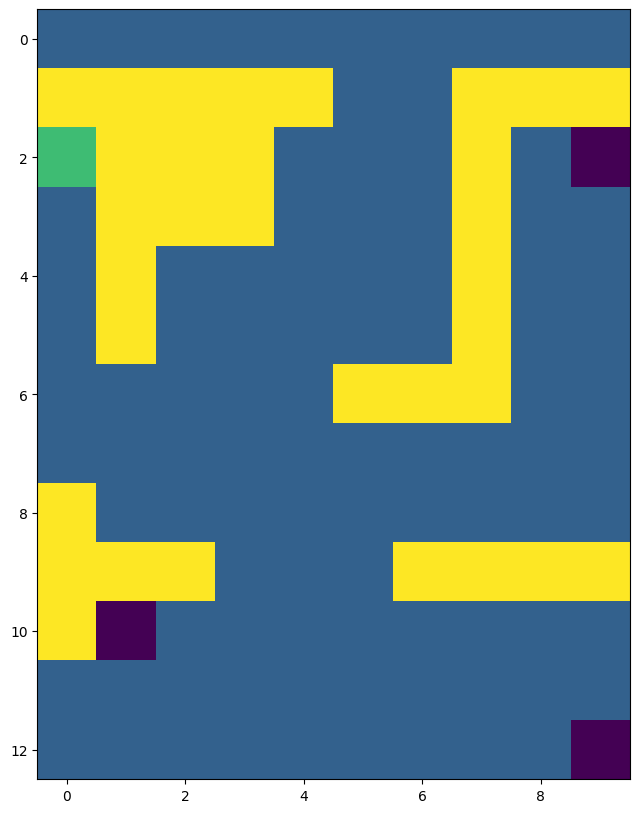

Results of the DP agent:



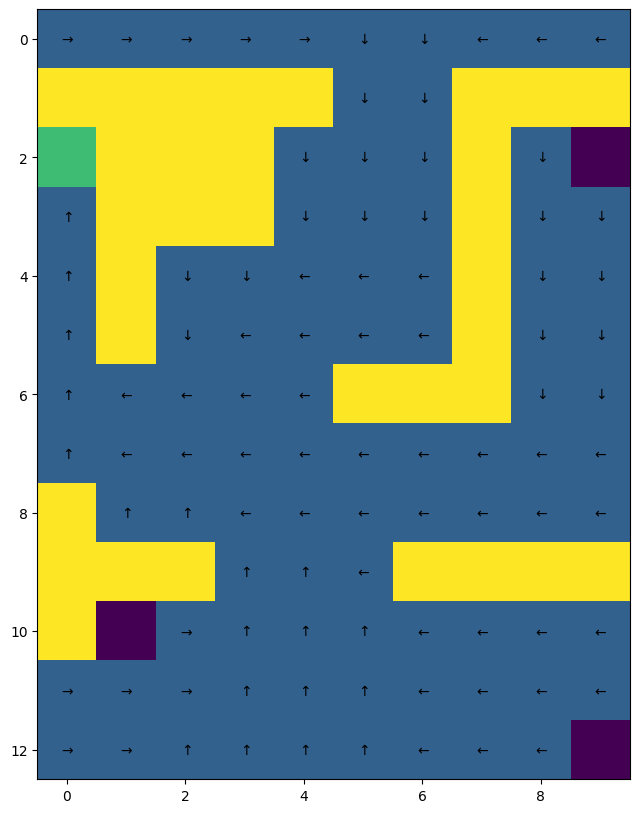

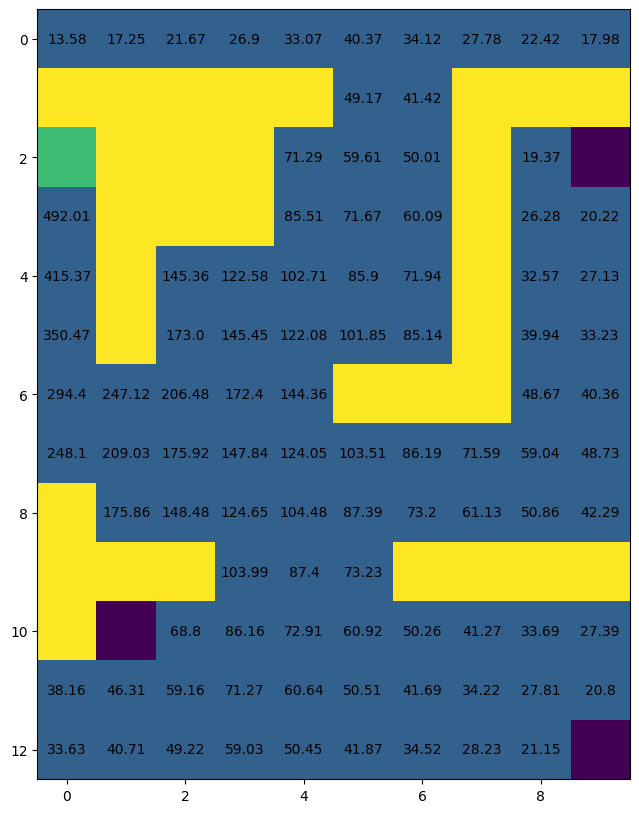

Results of the MC agent:



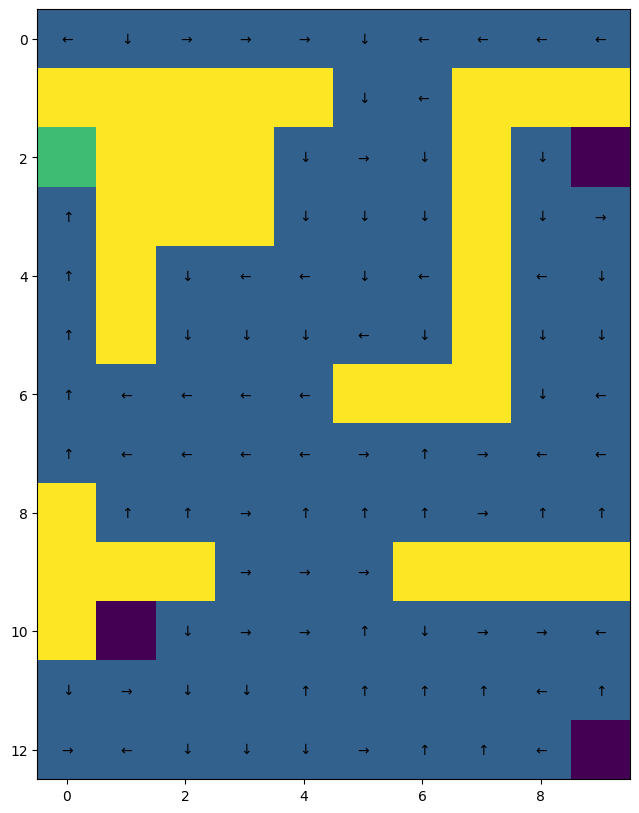

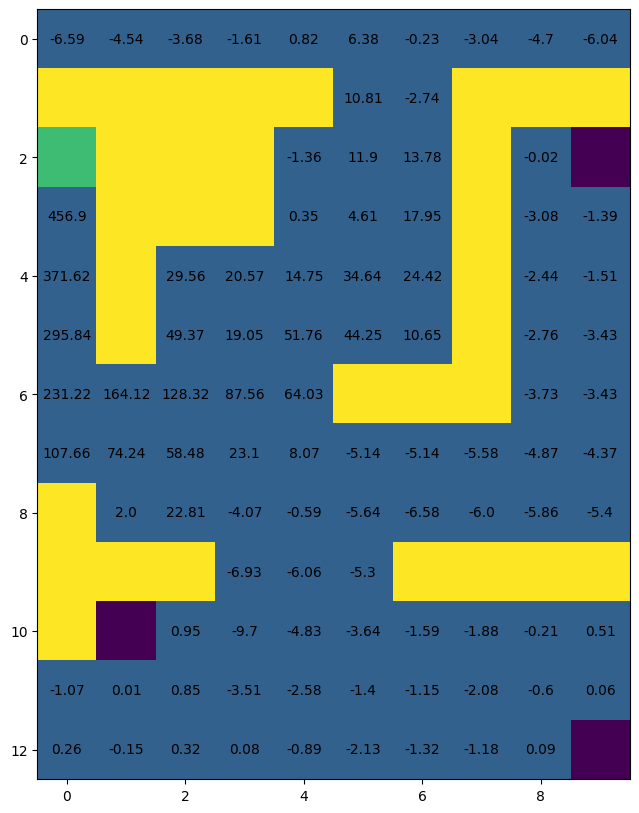

Results of the TD agent:



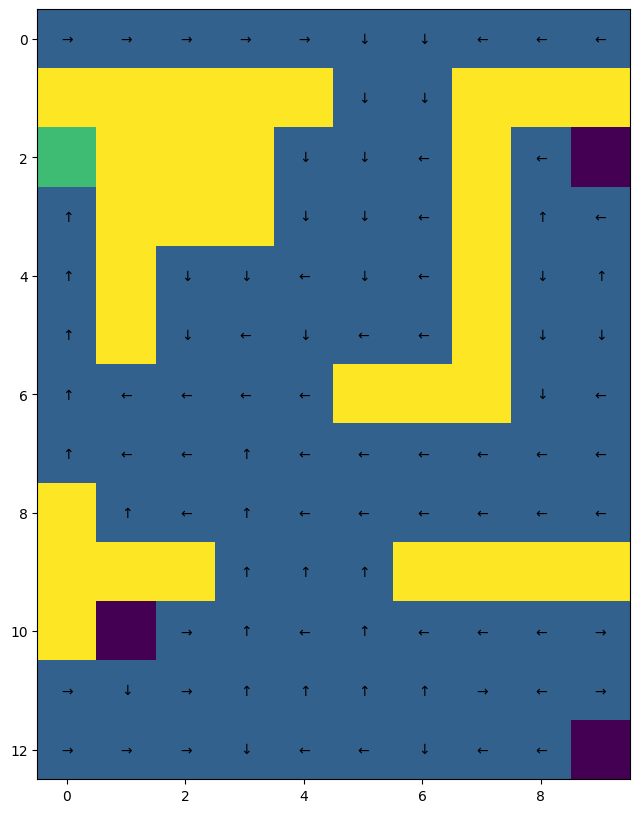

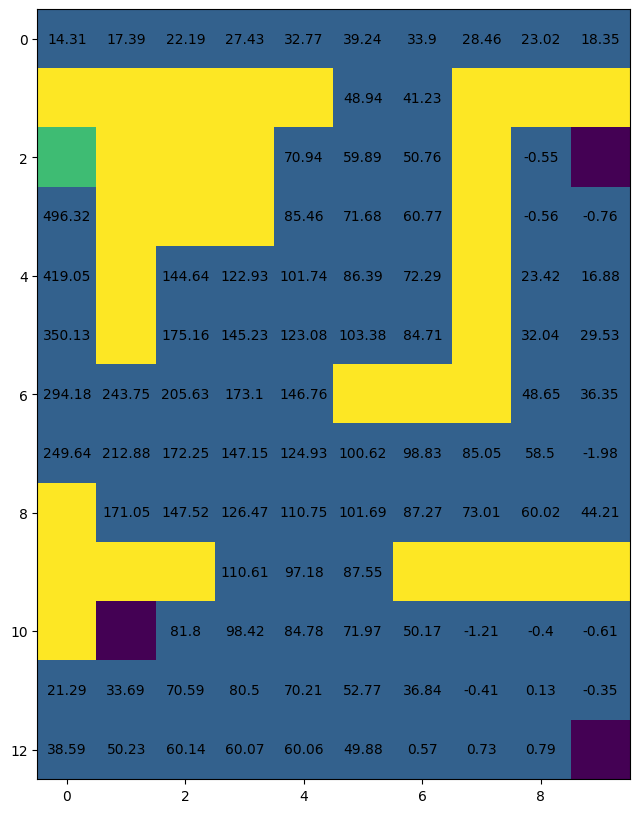

In [72]:
# Example main (can be edited)

### Question 0: Defining the environment

print("Creating the Maze:\n")
maze = Maze()


### Question 1: Dynamic programming

dp_agent = DP_agent()
dp_policy, dp_value = dp_agent.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy)
maze.get_graphics().draw_value(dp_value)


### Question 2: Monte-Carlo learning

mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.solve(maze)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

####
# num_runs = 25
# all_total_rewards = []
# maze = Maze()
# mc_agent = MC_agent()

# for run in range(num_runs): 
#     mc_policy, mc_values, total_rewards = mc_agent.solve(maze)
#     all_total_rewards.append(total_rewards)

# mean_rewards = np.mean(all_total_rewards, axis=0)
# std_rewards = np.std(all_total_rewards, axis=0)
# plt.figure(figsize=(10, 6))
# plt.plot(np.arange(1, len(mean_rewards) + 1), mean_rewards, label="Mean")
# plt.fill_between(np.arange(1, len(mean_rewards) + 1), mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label="Standard Deviation")
# plt.xlabel("Episodes")
# plt.ylabel("Total Non-Discounted Sum of Reward")
# plt.title("Learning Curve (Monte Carlo Learning) - 25 training runs")
# plt.legend()
# plt.grid(True)
# plt.show()

### Question 3: Temporal-Difference learning

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.solve(maze)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(td_policy)
maze.get_graphics().draw_value(td_values[-1])